#Google Colab Lab Assignment – Text Classification using LSTM

Course Name: Generative AI

Lab Title: Text Classification using Embedding Layer and LSTM Network

Student Name: Tanishka Vishnu Tapkir

PRN Number: 202401110071

Batch: A3

Date of Submission: 09/09/2026



## Introduction and Dataset

This project is based on Text Classification using an Embedding Layer and LSTM Network. The model learns from text data and classifies it into different categories.

For this project, the Reuters Newswire Dataset is used. It is available directly in the TensorFlow/Keras library and contains news articles from multiple categories.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [27]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset Name      : IMDB Movie Reviews Dataset")
print("Dataset Source    : TensorFlow / Keras")
print("Task Type         : Binary Classification")

print("\nTraining Samples  :", len(X_train))
print("Testing Samples   :", len(X_test))

print("\nClasses:")
print("0 = Negative Review")
print("1 = Positive Review")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DATASET INFORMATION
Dataset Name      : IMDB Movie Reviews Dataset
Dataset Source    : TensorFlow / Keras
Task Type         : Binary Classification

Training Samples  : 25000
Testing Samples   : 25000

Classes:
0 = Negative Review
1 = Positive Review


#Explore the Dataset

In this step, the dataset is explored to understand the text sequences and their corresponding class labels.

In [28]:
print("First Review Sequence:")
print(X_train[0][:50])

print("\nFirst Review Label:")
print(y_train[0])

if y_train[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

First Review Sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447]

First Review Label:
1
Sentiment: Positive


# Analyze Text Sequence Length

Different news articles have different numbers of words.

Therefore, the sequence length is analyzed before preprocessing the data.

In [29]:
sequence_lengths = [len(sequence) for sequence in X_train]

print("Minimum Length:", min(sequence_lengths))
print("Maximum Length:", max(sequence_lengths))
print("Average Length:", np.mean(sequence_lengths))

Minimum Length: 11
Maximum Length: 2494
Average Length: 238.71364


## Visualization of Sequence Length

The following graph shows the distribution of text sequence lengths in the training dataset.

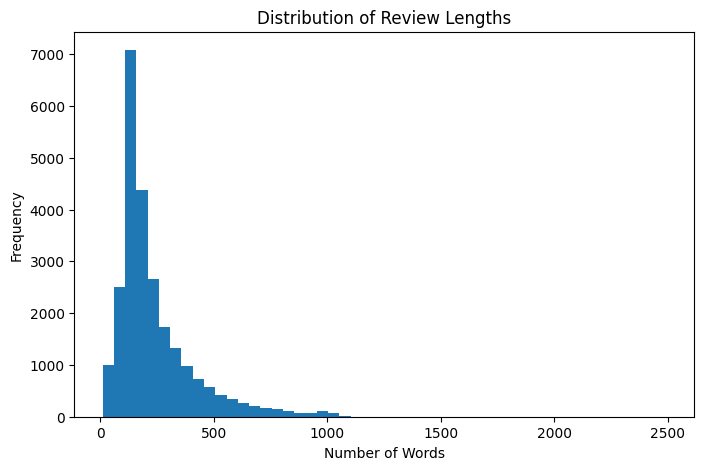

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(sequence_lengths, bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Data Preprocessing

Neural networks require input sequences of the same length.

Therefore, padding is applied to make all text sequences have a fixed length.

In [31]:
max_length = 250

X_train_pad = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training Shape:", X_train_pad.shape)
print("Testing Shape :", X_test_pad.shape)

Training Shape: (25000, 250)
Testing Shape : (25000, 250)


# Define Model Parameters

The following parameters are used to define the vocabulary size, embedding dimension, LSTM units, and number of output classes.

In [9]:
vocab_size = 10000
embedding_dim = 128
lstm_units = 128

num_classes = len(np.unique(y_train))

print("Vocabulary Size :", vocab_size)
print("Embedding Size  :", embedding_dim)
print("LSTM Units      :", lstm_units)
print("Number of Classes:", num_classes)

Vocabulary Size : 10000
Embedding Size  : 128
LSTM Units      : 128
Number of Classes: 46


# Build the Deep Learning Model

The model architecture consists of the following layers:

1. **Embedding Layer**
2. **LSTM Layer**
3. **Dropout Layer**
4. **Dense Hidden Layer**
5. **Softmax Output Layer**

The Embedding layer converts word indices into dense vectors, while the LSTM learns sequential patterns from the text.

In [32]:
model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.0
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using the Adam optimizer and Sparse Categorical Crossentropy loss.

Accuracy is used as the main metric during training.

In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Early Stopping

Early Stopping is used to prevent unnecessary training.

The training process stops when the validation loss does not improve for several epochs, and the best model weights are restored.

In [34]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [35]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 500ms/step - accuracy: 0.5118 - loss: 0.6929 - val_accuracy: 0.5392 - val_loss: 0.6881
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 410ms/step - accuracy: 0.5714 - loss: 0.6566 - val_accuracy: 0.5236 - val_loss: 0.6872
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 409ms/step - accuracy: 0.6106 - loss: 0.5999 - val_accuracy: 0.6006 - val_loss: 0.6271
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 131s 420ms/step - accuracy: 0.7190 - loss: 0.5397 - val_accuracy: 0.6522 - val_loss: 0.6500
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 421ms/step - accuracy: 0.8540 - loss: 0.3775 - val_accuracy: 0.7986 - val_loss: 0.4918
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 422ms/step - accuracy: 0.9116 - loss: 0.2459 - val_accuracy: 0.8348 - val_loss: 0.4522
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 131s 420ms/step - accuracy: 0.9446 - loss: 0.1679 - val_accuracy: 0.8522 - val_loss: 0.4968
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 416ms/step - accuracy: 0.9642 -

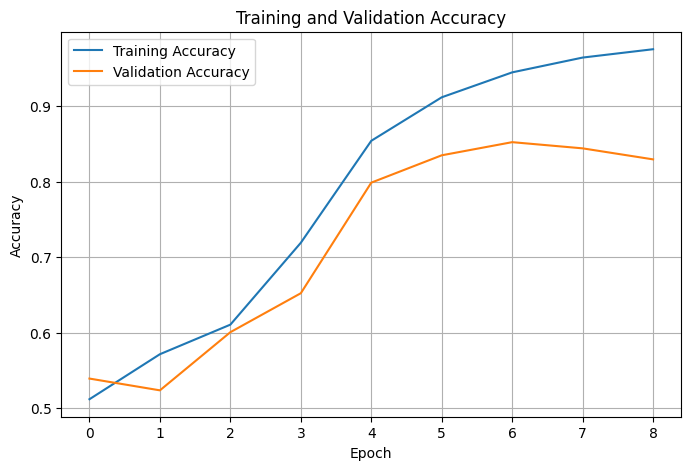

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

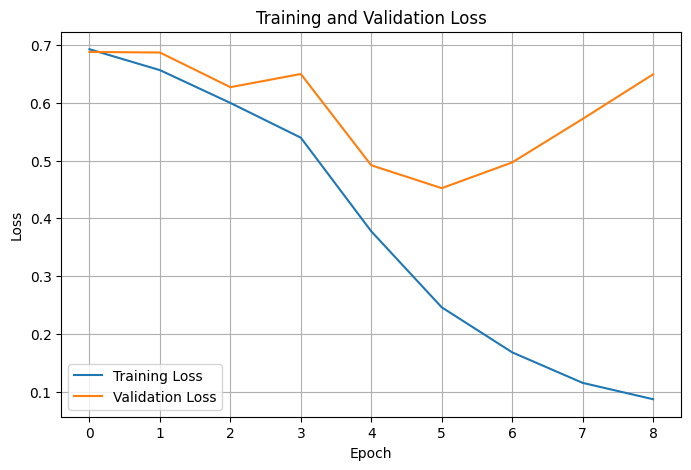

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [38]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

FINAL MODEL PERFORMANCE
Test Loss     : 0.4788
Test Accuracy : 82.59 %


In [39]:
predictions = model.predict(X_test_pad)

y_pred = (predictions > 0.5).astype(int).flatten()

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Labels:")
print(y_test[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step
First 10 Predictions:
[0 1 1 1 1 0 0 0 1 1]

First 10 Actual Labels:
[0 1 1 0 1 1 1 0 0 1]


In [40]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)

print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")

CLASSIFICATION METRICS
Accuracy  : 82.59 %
Precision : 82.47 %
Recall    : 82.78 %
F1 Score  : 82.62 %


In [41]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.82      0.83     12500
    Positive       0.82      0.83      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



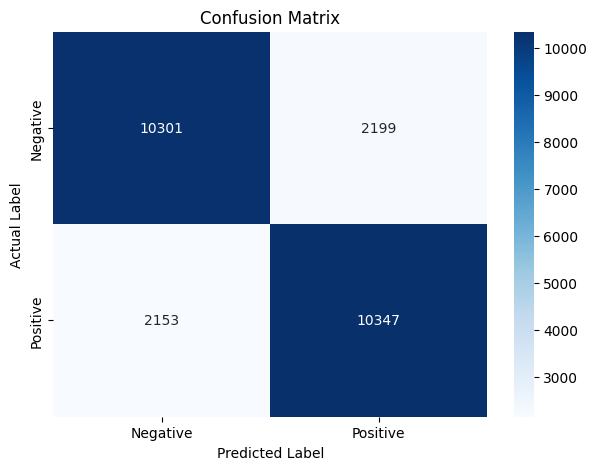

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [43]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score (%)": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

results["Score (%)"] = results["Score (%)"].round(2)

results

,Metric,Score (%)
0,Accuracy,82.59
1,Precision,82.47
2,Recall,82.78
3,F1 Score,82.62


In [44]:
model.save("text_classification_lstm.keras")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this project, a multi-class text classification model was developed using an Embedding Layer and LSTM Network.

The Reuters Newswire Dataset was used for training and testing the model. The text sequences were padded before being given to the neural network.

The Embedding Layer converted words into numerical vector representations, while the LSTM Network learned patterns from the text sequences.

The model performance was evaluated using Accuracy, Precision, Recall, F1 Score, Classification Report, and Confusion Matrix.